# **PyGLAM — verification against reference distributions**

Checks that the method-of-moments fit implemented in `pyGLAM` recovers well-known distributions,
and quantifies how the quality of that fit improves with the sample size. Both parameterizations
shipped by the library are exercised: **FKML** (`GlamFKML`) and **RS** (`GlamRS`).

Four targets are used, chosen to exercise different shapes: **Normal** (symmetric, unbounded),
**Gumbel** (right-skewed, exponential tail), **Uniform** (bounded, no mode) and **Lognormal**
(right-skewed, heavier tail).

| Metric | What it measures |
|---|---|
| `KS` | $\sup_x \lvert F_{\mathrm{GLD}}(x) - F_{\mathrm{target}}(x)\rvert$, against the **analytical** target CDF |
| `KS 2-sample` | two-sample Kolmogorov–Smirnov between a large reference sample from the target and an equally large sample drawn from the fitted GLD |
| `KS test (N)` / `p-value` | the same test run at the **sample size the practitioner has**, $N$ against $N$ |
| `KL` | $D(q\lVert p)$, the fitted GLD relative to the target (KDE-based, via `pyglam.Performance`) |
| `Wasserstein` | earth-mover distance between the two samples |
| `R2 (PDF)` | $R^2$ between the two KDE-estimated densities |
| `err P5/P50/P95` | quantile error, normalised by the $P_5$–$P_{95}$ spread |
| `valid` | whether the fitted quantile function is finite and non-decreasing on $(0,1)$ |

Two families of metric are reported side by side on purpose. `KS` is computed against the
analytical target, so it measures **the approximation error of the GLD family itself** and is the
quantity whose convergence rate is analysed in Section 6.1. The sample-based metrics are what a
practitioner can actually compute without knowing the target.

The hypothesis test is reported at two scales, and the difference between them is instructive.
Against 20 000 reference draws the test asks whether the GLD *is* the target; since it is not,
the test rejects essentially always and the p-value carries no information. `KS test (N)` instead
runs the test at the sample size actually available, which is the question a practitioner asks,
and its rejection rate shows the test gaining power as $N$ grows.

Everything below is built on `pyglam`'s own public API — `fit_lambdas` / `.pdf` / `.ppf` / `.rvs`
and `Performance.performance` — with no local reimplementation of the GLD math.

> **On the direction of the KL divergence.** With $\lambda_3, \lambda_4 > 0$ the FKML GLD has
> *compact* support, while Normal, Gumbel and Lognormal do not. $D(p\lVert q)$ is therefore
> infinite by construction, and only $D(q\lVert p)$ is finite — the column reports the latter.

> **On validity.** Moment matching is not injective: different parameter vectors reproduce the
> same four moments. Some of them are not distributions at all — a quantile function that
> decreases somewhere on $(0,1)$. `fit_lambdas` reports `success=True` for those, so every fit is
> screened here and the failure rate is reported as a result rather than silently dropped.

## **1. Libraries**

In [1]:
%matplotlib inline
import sys
import time
from pathlib import Path

REPO = Path.cwd()
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams.update({
                        'font.family': 'serif',
                        'mathtext.fontset': 'cm',
                        'axes.unicode_minus': False
                    })

import pyglam as glam

print('repo:', REPO)

repo: /home/casa-wand/steam2tb/pyGLAM


## **2. Config**

`n_rep` is what makes the convergence legible: a single fit at `N = 50` is dominated by sampling
noise, so every cell is averaged over independent replicates.

The seed of each replicate depends on the target and on `N`, but **not** on the parameterization,
so FKML and RS are fitted to the *same* samples. The comparison between the two is therefore
paired, and any difference between them is a property of the parameterization rather than of the
draw.

In [2]:
families = {
                'FKML': glam.GlamFKML,
                'RS':   glam.GlamRS,
            }

targets = {
               'Normal':    st.norm(loc=0.0, scale=1.0),
               'Gumbel':    st.gumbel_r(loc=0.0, scale=1.0),
               'Uniform':   st.uniform(loc=0.0, scale=1.0),
               'Lognormal': st.lognorm(s=0.4, scale=1.0),
           }

sizes      = (50, 200, 1000, 5000)   # sample sizes swept
n_rep      = 20                      # independent replicates per (family, distribution, N) cell
n_starts   = 15                      # pyGLAM multi-start attempts per fit
n_showcase = 1000                    # sample size used in the density figure

fig_dir    = REPO / 'texto'          # where the manuscript keeps its figures
fig_format = 'pdf'
fig_dpi    = 300
fig_dir.mkdir(parents=True, exist_ok=True)

# categorical palette in fixed order, one marker per series as a secondary encoding so the
# figure survives greyscale printing
series  = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
markers = ['o', 's', '^', 'D']
gray_f, gray_e, ink = '#d9d9d6', '#9c9a91', '#3d3d3a'

labels = {
             'pt': dict(dens='Densidade', x='$x$', sample='Amostra', fit='GLD ajustada',
                        n='Tamanho amostral $N$', ks=u'Distância KS até a CDF alvo',
                        names={'Normal': 'Normal', 'Gumbel': 'Gumbel',
                               'Uniform': 'Uniforme', 'Lognormal': 'Lognormal'}),
             'en': dict(dens='Density', x='$x$', sample='Sample', fit='Fitted GLD',
                        n='Sample size $N$', ks='KS distance to target CDF',
                        names={k: k for k in targets}),
         }

print(f'{len(families)} parameterizations x {len(targets)} targets x {len(sizes)} sizes x {n_rep} reps'
      f' = {len(families) * len(targets) * len(sizes) * n_rep} fits')

2 parameterizations x 4 targets x 4 sizes x 20 reps = 640 fits


## **3. Fitting and scoring one sample**

### 3.1 Screening the fitted parameters

`fit_lambdas` reports optimizer termination, not distributional validity. Four-moment matching
admits several roots, and some of them have a quantile function that is not monotone — the
"distribution" runs backwards. Those fits reproduce the four moments to machine precision and are
still returned with `success=True`.

`check_model` is the screen: it evaluates the quantile function on a dense probability grid and
requires it to be finite and non-decreasing. It returns the grid of quantiles as well, because the
analytical KS distance is computed from exactly the same evaluation.

In [3]:
U_GRID = np.linspace(1e-6, 1.0 - 1e-6, 4001)


def check_model(model, u=U_GRID):
    """Evaluate the quantile function on a probability grid and check it is a distribution.

    :param model: Fitted `GlamFKML` or `GlamRS` instance
    :param u: Probability grid the quantile function is evaluated on

    :return: Tuple `(valid, x)` with the validity flag and the quantiles, `None` when unusable
    """

    try:
        x = np.asarray(model.ppf(u), dtype=float)
    except Exception:
        return False, None

    if not np.all(np.isfinite(x)):
        return False, None

    # a strictly decreasing stretch anywhere means the parameters are not a distribution;
    # the tolerance absorbs round-off in the quantile evaluation, not a real decrease
    return bool(np.all(np.diff(x) >= -1e-10)), x


def ks_analytic(dist, x, u=U_GRID):
    """Supremum distance between the fitted GLD CDF and the analytical target CDF.

    Parameterising by `u` turns `sup_x |F_gld(x) - F_target(x)|` into `sup_u |u - F_target(Q(u))|`,
    which needs no root finding. The two extra terms cover the probability mass the target places
    outside a compact GLD support, where `F_gld` is pinned at 0 or 1.

    :param dist: Frozen `scipy.stats` target distribution
    :param x: Quantiles of the fitted GLD on the grid `u`
    :param u: Probability grid

    :return: Kolmogorov-Smirnov distance to the analytical target
    """

    cdf_target = dist.cdf(x)

    return float(max(np.max(np.abs(cdf_target - u)),
                     cdf_target[0],
                     1.0 - cdf_target[-1]))

### 3.2 Fit + score one sample, on `pyglam` alone

`evaluate_gld_fit` draws one sample from the target, fits a GLD to it with `fit_lambdas`, screens
the result, and scores it two ways: against the **analytical** target through `ks_analytic`, and
against a **large reference sample** from the target through `pyglam.Performance` — the same tool
used to score a surrogate against raw data everywhere else.

The quantile errors are the one piece kept as plain NumPy: `Performance`'s own relative error
divides by the reference quantile itself, which blows up for a target like the Normal whose median
sits at zero. Normalising by the $P_5$–$P_{95}$ spread instead keeps it well-behaved for every
target tested here.

In [4]:
def evaluate_gld_fit(name, dist, n, family='FKML', seed=42, n_starts=15, n_ref=20000, n_grid=400):
    """Draw one sample from a target distribution, fit a GLD to it and score the fit.

    :param name: Label of the target distribution, carried through to the results table
    :param dist: Frozen `scipy.stats` distribution to sample from and compare against
    :param n: Sample size
    :param family: Key of `families`, selecting the GLD parameterization
    :param seed: Seed of the sample, the GLD fit's multi-start, and the reference/GLD samples
    :param n_starts: Number of pyglam multi-start attempts
    :param n_ref: Size of the reference and GLD samples scored by `Performance`
    :param n_grid: Grid resolution `Performance` uses for its KDE-based metrics

    :return: Dictionary with the fitted lambdas, goodness-of-fit metrics and support endpoints
    """

    cls    = families[family]
    rng    = np.random.default_rng(seed)
    sample = dist.rvs(size=n, random_state=rng)

    t0      = time.perf_counter()
    sol     = cls().fit_lambdas(sample, method='least_squares', n_starts=n_starts, seed=seed)
    elapsed = time.perf_counter() - t0

    lambdas = np.asarray(sol.x, dtype=float)
    fitted  = cls(*lambdas)

    row = {'Family': family, 'Distribution': name, 'N': n,
           'lambda 1': lambdas[0], 'lambda 2': lambdas[1],
           'lambda 3': lambdas[2], 'lambda 4': lambdas[3],
           'success': bool(sol.success), 'fit time (s)': elapsed}

    valid, x_grid = check_model(fitted)
    row['valid'] = valid

    # What a selection rule that ignores monotonicity would have returned. The fit result
    # carries the per-candidate diagnostics, so the older rule -- pool by moment domain, pick
    # the lowest residual, break ties on quantile distance -- is replayed without refitting.
    pool       = np.flatnonzero(sol.in_domain) if sol.in_domain.any() else np.arange(sol.costs.size)
    best_cost  = float(sol.costs[pool].min())
    tied       = pool[sol.costs[pool] <= best_cost + 1e-8 + 1e-2 * best_cost]
    unscreened = int(tied[np.argmin(sol.distances[tied])])
    row['valid unscreened'] = bool(sol.monotone[unscreened])
    row['candidates valid (%)'] = 100.0 * float(np.mean(sol.monotone))

    nan_cols = ['KS', 'KS 2-sample', 'KS test (N)', 'p-value', 'KL', 'Wasserstein', 'R2 (PDF)',
                'err P5 (%)', 'err P50 (%)', 'err P95 (%)', 'support min', 'support max']

    if not valid:
        # an invalid quantile function makes every downstream metric meaningless, not merely bad
        row.update({column: np.nan for column in nan_cols})
        return row

    row['KS'] = ks_analytic(dist, x_grid)

    ref_n      = max(n, n_ref)
    dist_ref   = dist.rvs(size=ref_n, random_state=rng)
    gld_sample = fitted.rvs(size=ref_n, random_state=seed)
    perf       = glam.Performance(n_grid=n_grid).performance(dist_ref, gld_sample)

    row['KS 2-sample'] = perf['ks_statistic']
    row['KL']          = perf['kl_divergence']
    row['Wasserstein'] = perf['wasserstein']
    row['R2 (PDF)']    = perf['r2_pdf']

    # The test above runs on n_ref draws per side, so it asks whether the GLD *is* the target.
    # It is not, and at that scale the test rejects essentially always. Re-running it at the
    # sample size actually available is the question a practitioner asks of their own data.
    test_target      = dist.rvs(size=n, random_state=rng)
    test_gld         = fitted.rvs(size=n, random_state=seed + 1)
    ks_n             = st.ks_2samp(test_target, test_gld)
    row['KS test (N)'] = float(ks_n.statistic)
    row['p-value']     = float(ks_n.pvalue)

    quantiles = np.array([0.05, 0.50, 0.95])
    q_target  = dist.ppf(quantiles)
    q_gld     = fitted.ppf(quantiles)
    spread    = dist.ppf(0.95) - dist.ppf(0.05)
    err_q     = np.abs(q_gld - q_target) / spread * 100.0

    row['err P5 (%)'], row['err P50 (%)'], row['err P95 (%)'] = err_q
    row['support min'], row['support max'] = x_grid[0], x_grid[-1]

    return row

In [5]:
def study_gld_fits(families, targets, sizes, n_rep=20, n_starts=15, base_seed=0, verbose=True):
    """Repeat `evaluate_gld_fit` over independent samples for every cell of the design.

    Replication matters here: a single fit at N = 50 is dominated by sampling noise, so the
    convergence of the method of moments only becomes legible in the average over replicates.
    The seed does not depend on the parameterization, so FKML and RS see identical samples.

    :param families: Mapping from label to pyglam distribution class
    :param targets: Mapping from label to frozen `scipy.stats` distribution
    :param sizes: Sample sizes to sweep
    :param n_rep: Number of independent replicates per cell
    :param n_starts: Number of pyglam multi-start attempts per fit
    :param base_seed: Base seed; each replicate offsets it
    :param verbose: Whether to report progress per (parameterization, distribution)

    :return: DataFrame with one row per replicate
    """

    rows = []
    for family in families:
        for name, dist in targets.items():
            if verbose:
                print(f'  {family:5s} {name} ...', end='', flush=True)
            for n in sizes:
                for r in range(n_rep):
                    row = evaluate_gld_fit(name, dist, n, family=family,
                                           seed=base_seed + 1000 * r + n, n_starts=n_starts)
                    row['rep'] = r
                    rows.append(row)
            if verbose:
                n_bad = sum(1 for row in rows[-len(sizes) * n_rep:] if not row['valid'])
                print(f' done ({n_bad} invalid)' if n_bad else ' done')

    return pd.DataFrame(rows)

## **4. Run the study**

In [6]:
print('=' * 64)
print('FITTING THE GLD TO THE REFERENCE DISTRIBUTIONS')
print('=' * 64)

t0  = time.perf_counter()
raw = study_gld_fits(families, targets, sizes, n_rep=n_rep, n_starts=n_starts)

print(f'\n{len(raw)} fits completed in {time.perf_counter() - t0:.1f} s')
raw.head()

FITTING THE GLD TO THE REFERENCE DISTRIBUTIONS
  FKML  Normal ...

 done
  FKML  Gumbel ...

 done
  FKML  Uniform ...

/home/casa-wand/steam2tb/pyGLAM/pyglam/glam.py:304: RuntimeWarning: invalid value encountered in scalar divide
  term4 = (4.0 / (l3 * l4**3)) * (sc.special.gamma(l3 + 1.0) * sc.special.gamma(3.0*l4 + 1.0)) / sc.special.gamma(l3 + 3.0*l4 + 2.0)


/home/casa-wand/steam2tb/pyGLAM/pyglam/glam.py:302: RuntimeWarning: invalid value encountered in scalar divide
  term2 = (4.0 / (l3**3 * l4)) * (sc.special.gamma(3.0*l3 + 1.0) * sc.special.gamma(l4 + 1.0)) / sc.special.gamma(3.0*l3 + l4 + 2.0)


...

 done
  RS    Gumbel ...

 done
  RS    Uniform ...

 done
  RS    Lognormal ...

 done

640 fits completed in 284.7 s


,Family,Distribution,N,lambda 1,lambda 2,lambda 3,lambda 4,success,fit time (s),valid,...,Wasserstein,R2 (PDF),KS test (N),p-value,err P5 (%),err P50 (%),err P95 (%),support min,support max,rep
0,FKML,Normal,50,-0.224975,1.683321,0.032577,-0.019449,True,0.046624,True,...,0.207239,0.947268,0.24,0.112385,7.453808,6.613747,2.059560,-6.833867,9.190693,0
1,FKML,Normal,50,-0.148479,1.184249,0.473638,0.020307,True,0.057503,True,...,0.176270,0.924034,0.12,0.869262,5.722290,2.012504,18.789369,-1.928743,10.023964,1
2,FKML,Normal,50,-0.107917,1.704659,0.073274,0.184134,True,0.060322,True,...,0.165166,0.953968,0.16,0.548685,0.333921,3.728081,13.133462,-5.204691,2.827671,2
3,FKML,Normal,50,0.267512,1.265675,0.077356,0.343157,True,0.048702,True,...,0.165301,0.927258,0.24,0.112385,4.867626,6.738421,1.854683,-6.438316,2.549833,3
4,FKML,Normal,50,0.011951,1.304309,0.270317,0.315507,True,0.039245,True,...,0.052951,0.992486,0.12,0.869262,3.694611,0.142054,5.662163,-2.756572,2.410890,4


## **5. Validity of the fits**

The screen from Section 3.1, aggregated. Three columns say three different things:

- `success (%)` is what the optimizer reports — it is 100% everywhere, and means nothing here;
- `valid unscreened (%)` is what a selection rule that ranks candidates by residual alone would
  have returned, replayed from the per-candidate diagnostics without refitting;
- `valid (%)` is what the library returns once candidates are screened for a non-decreasing
  quantile function.

`candidates valid (%)` is the share of the multi-start candidates that are distributions at all,
and it explains why the screen costs nothing: a valid candidate is almost always available.

In [7]:
validity = (raw.groupby(['Family', 'Distribution'], as_index=False)
               .agg(fits=('valid', 'size'),
                    success_rate=('success', 'mean'),
                    unscreened_rate=('valid unscreened', 'mean'),
                    valid_rate=('valid', 'mean'),
                    cand=('candidates valid (%)', 'mean')))
validity['success (%)']         = validity.pop('success_rate') * 100
validity['valid unscreened (%)'] = validity.pop('unscreened_rate') * 100
validity['valid (%)']           = validity.pop('valid_rate') * 100
validity['candidates valid (%)'] = validity.pop('cand')

display(validity.round(1))

bad = raw.loc[~raw['valid unscreened'], ['Family', 'Distribution', 'N', 'rep']]
print(f"\n{len(bad)} of {len(raw)} fits would be invalid without the monotonicity screen; "
      f"{(~raw['valid']).sum()} are invalid with it")
bad.groupby(['Family', 'Distribution']).size()

,Family,Distribution,fits,success (%),valid unscreened (%),valid (%),candidates valid (%)
0,FKML,Gumbel,80,100.0,100.0,100.0,99.9
1,FKML,Lognormal,80,100.0,100.0,100.0,99.2
2,FKML,Normal,80,100.0,100.0,100.0,100.0
3,FKML,Uniform,80,100.0,100.0,100.0,99.5
4,RS,Gumbel,80,100.0,91.2,100.0,73.4
5,RS,Lognormal,80,100.0,97.5,100.0,59.0
6,RS,Normal,80,100.0,98.8,100.0,73.6
7,RS,Uniform,80,100.0,75.0,100.0,62.6



30 of 640 fits would be invalid without the monotonicity screen; 0 are invalid with it


Family  Distribution
RS      Gumbel           7
        Lognormal        2
        Normal           1
        Uniform         20
dtype: int64

## **6. Summary**

Averages over the replicates, computed on the **valid** fits only; `invalid (%)` carries the
discarded fraction so the two are never read apart. `KS` is the distance to the analytical target, `KS 2-sample`
is its sample-based counterpart at reference scale, and `rejection rate (%)` counts how often the
test at size $N$ rejects at the 5\% level.

In [8]:
metric_cols = ['KS', 'KS 2-sample', 'KS test (N)', 'KL', 'Wasserstein', 'R2 (PDF)',
               'err P5 (%)', 'err P50 (%)', 'err P95 (%)', 'p-value']

keys    = ['Family', 'Distribution', 'N']
good    = raw[raw['valid']]
summary = good.groupby(keys, as_index=False)[metric_cols].mean()

counts = raw.groupby(keys, as_index=False).agg(invalid=('valid', lambda v: 100.0 * (~v).mean()))
reject = good.assign(rej=good['p-value'] < 0.05).groupby(keys, as_index=False).agg(rej=('rej', 'mean'))

summary = summary.merge(counts, on=keys).merge(reject, on=keys)
summary['rejection rate (%)'] = summary.pop('rej') * 100
summary = summary.rename(columns={'invalid': 'invalid (%)'})

summary.round(4)

,Family,Distribution,N,KS,KS 2-sample,KS test (N),KL,Wasserstein,R2 (PDF),err P5 (%),err P50 (%),err P95 (%),p-value,invalid (%),rejection rate (%)
0,FKML,Gumbel,50,0.0818,0.0833,0.1870,0.3581,0.2063,0.8831,5.0094,3.8795,9.9177,0.4426,0.0,10.0
1,FKML,Gumbel,200,0.0476,0.0499,0.0998,0.0813,0.1087,0.9248,2.4585,1.5738,4.9447,0.3981,0.0,15.0
2,FKML,Gumbel,1000,0.0460,0.0480,0.0689,0.0751,0.1045,0.8541,1.4974,1.1399,4.8447,0.2365,0.0,25.0
3,FKML,Gumbel,5000,0.0436,0.0459,0.0492,0.0759,0.0893,0.8240,1.2300,0.9278,3.2420,0.2656,0.0,40.0
4,FKML,Lognormal,50,0.0940,0.0956,0.1790,0.2218,0.0797,0.8615,4.0724,4.1686,13.7303,0.4828,0.0,10.0
5,FKML,Lognormal,200,0.0738,0.0748,0.1168,0.1245,0.0509,0.8421,2.7432,2.5583,6.3579,0.2819,0.0,25.0
6,FKML,Lognormal,1000,0.0303,0.0326,0.0496,0.0485,0.0243,0.9392,1.1390,0.8482,2.5278,0.3543,0.0,10.0
7,FKML,Lognormal,5000,0.0149,0.0186,0.0228,0.0247,0.0148,0.9924,0.5691,0.3662,1.1010,0.2057,0.0,10.0
8,FKML,Normal,50,0.0659,0.0681,0.1680,0.1274,0.1491,0.9384,5.5465,3.3654,7.1805,0.5353,0.0,5.0
9,FKML,Normal,200,0.0366,0.0380,0.1075,0.0316,0.0794,0.9849,3.5892,2.0393,2.2731,0.3187,0.0,15.0


### 6.1 Convergence rate

The error of a moment-based fit is the sum of two parts: a **sampling** part, from estimating the
first four moments on a finite sample, which decays at the theoretical rate $N^{-1/2}$; and a
**structural** part, from the GLD family not containing the target exactly, which does not depend
on $N$ at all.

The slope of $\log \mathrm{KS}$ against $\log N$ tells them apart. A slope near $-0.5$ with a high
$R^2$ means the error is purely sampling — the fit is as good as the data allows. A slope near
zero means a structural floor dominates, and more data will not help.

In [9]:
rates = []
for family in families:
    for name in targets:
        d = summary[(summary['Family'] == family) & (summary['Distribution'] == name)].sort_values('N')
        if len(d) < 2 or not np.all(np.isfinite(d['KS'].values)) or np.any(d['KS'].values <= 0):
            rates.append({'Family': family, 'Distribution': name,
                          'slope': np.nan, 'R2': np.nan, 'regime': 'not estimable'})
            continue

        x, y = np.log(d['N'].values), np.log(d['KS'].values)
        a, b = np.polyfit(x, y, 1)
        r2   = 1 - ((y - (a * x + b)) ** 2).sum() / ((y - y.mean()) ** 2).sum()
        rates.append({'Family': family, 'Distribution': name, 'slope': a, 'R2': r2,
                      'regime': 'sampling-limited' if a < -0.45 else
                                ('mixed' if a < -0.30 else 'structural floor')})

rates = pd.DataFrame(rates)
rates.round(3)

,Family,Distribution,slope,R2,regime
0,FKML,Normal,-0.524,0.994,sampling-limited
1,FKML,Gumbel,-0.122,0.684,structural floor
2,FKML,Uniform,-0.504,0.993,sampling-limited
3,FKML,Lognormal,-0.418,0.971,mixed
4,RS,Normal,-0.536,0.997,sampling-limited
5,RS,Gumbel,-0.303,0.963,mixed
6,RS,Uniform,-0.504,0.993,sampling-limited
7,RS,Lognormal,-0.229,0.897,structural floor


### 6.2 Fitted parameters and support

With $\lambda_3, \lambda_4 > 0$ the fitted GLD is **bounded**. For the unbounded targets this is
where the approximation necessarily breaks down, and it is the mechanism behind the residual error
seen in the extreme tail.

In [10]:
params = (good[good['N'] == max(sizes)]
             .groupby(['Family', 'Distribution'])[['lambda 1', 'lambda 2', 'lambda 3', 'lambda 4',
                                                   'support min', 'support max']].mean())
params.round(3)

lambda 1  lambda 2  lambda 3  lambda 4  support min  \
Family Distribution                                                        
FKML   Gumbel           0.648     0.945     1.674     2.245       -1.850   
       Lognormal        0.963     3.271     0.540    -0.041        0.391   
       Normal           0.004     1.465     0.133     0.138       -4.329   
       Uniform          0.505     1.171     1.811     1.854       -0.000   
RS     Gumbel           0.481     0.057    39.095     0.099       -3.759   
       Lognormal        1.556     0.322    96.503     0.252        0.038   
       Normal           0.017     0.198     0.137     0.133       -4.284   
       Uniform          0.500     2.002     1.886     1.901        0.000   

                     support max  
Family Distribution               
FKML   Gumbel             13.341  
       Lognormal           6.749  
       Normal              4.229  
       Uniform             0.999  
RS     Gumbel             11.629  
       Lognormal           4.703  
       Normal              4.275  
       Uniform             0.999

## **7. Density fits**

One row per parameterization. Both rows are fitted to the same sample of each target.

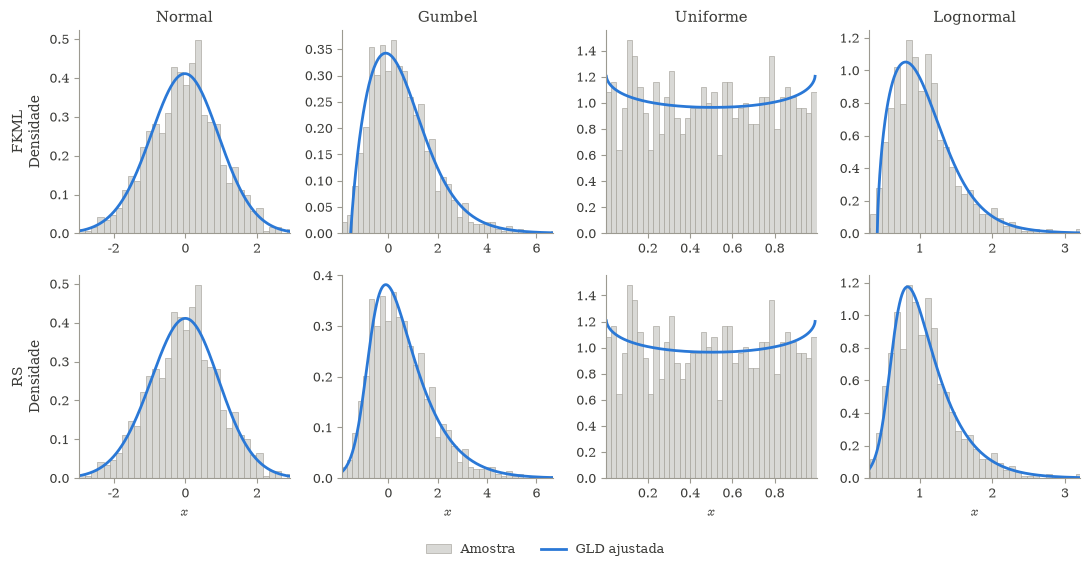

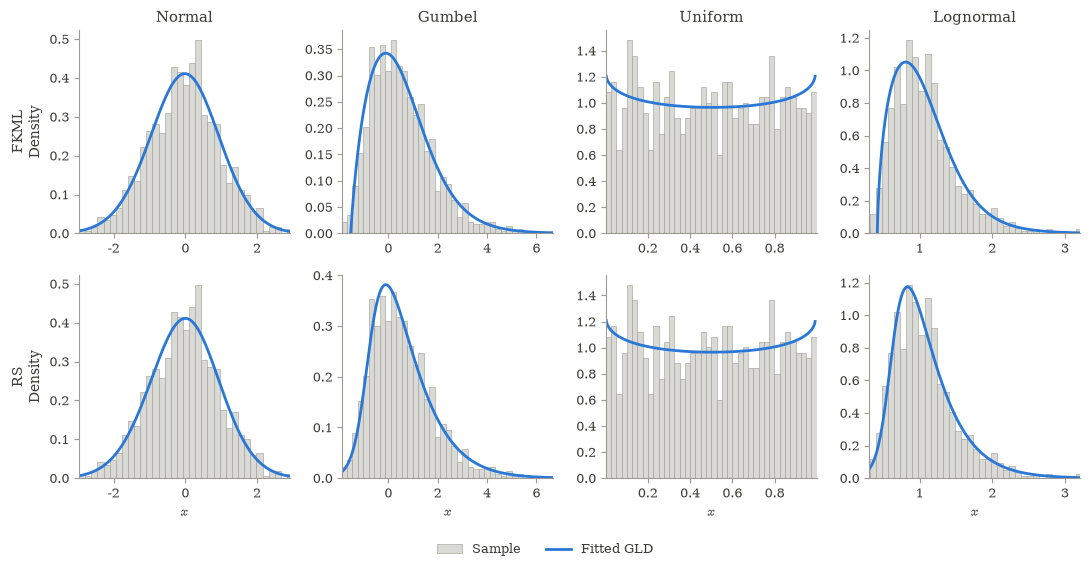

In [11]:
def plot_fits(lang, n=n_showcase, seed=42, save=True):
    L    = labels[lang]
    fig, axes = plt.subplots(len(families), len(targets), figsize=(11.0, 2.7 * len(families)),
                             squeeze=False)

    for row, family in enumerate(families):
        cls = families[family]
        for col, (name, dist) in enumerate(targets.items()):
            ax      = axes[row][col]
            sample  = dist.rvs(size=n, random_state=np.random.default_rng(seed))
            lambdas = cls().fit_lambdas(sample, method='least_squares',
                                        n_starts=n_starts, seed=seed).x
            fitted  = cls(*lambdas)
            valid, x_u = check_model(fitted)

            ax.hist(sample, bins=40, density=True, color=gray_f, edgecolor=gray_e,
                    linewidth=0.4, label=L['sample'])
            if valid:
                ax.plot(x_u, fitted.pdf(x_u), color=series[0], linewidth=2.0, label=L['fit'])

            if row == 0:
                ax.set_title(L['names'][name], fontsize=11, color=ink, pad=6)
            if row == len(families) - 1:
                ax.set_xlabel(L['x'], fontsize=10, color=ink)
            if col == 0:
                ax.set_ylabel(f"{family}\n{L['dens']}", fontsize=10, color=ink)

            ax.set_xlim(np.percentile(sample, 0.1), np.percentile(sample, 99.9))
            for s in ('top', 'right'):
                ax.spines[s].set_visible(False)
            for s in ('left', 'bottom'):
                ax.spines[s].set_color(gray_e); ax.spines[s].set_linewidth(0.8)
            ax.tick_params(colors=ink, labelsize=9, width=0.8, color=gray_e)

    # legend at figure level: inside the first panel it crosses its own curve
    h, lb = axes[0][0].get_legend_handles_labels()
    fig.legend(h, lb, frameon=False, fontsize=9, labelcolor=ink, ncol=2,
               loc='lower center', bbox_to_anchor=(0.5, -0.06))
    fig.tight_layout()

    if save:
        fig.savefig(fig_dir / f'z_pyglam_fits_{lang}.{fig_format}', bbox_inches='tight', dpi=fig_dpi)
    return fig


for lang in ('pt', 'en'):
    plot_fits(lang)
plt.show()

## **8. Convergence of the fit**

KS distance to the **analytical** target CDF against sample size, on log--log axes. The slope is
the convergence rate of the method of moments; a **plateau** means the residual gap is not
statistical but structural — the GLD family simply cannot represent that target exactly.

The dashed guide has slope $-1/2$, the theoretical sampling rate; a series parallel to it is
sampling-limited.

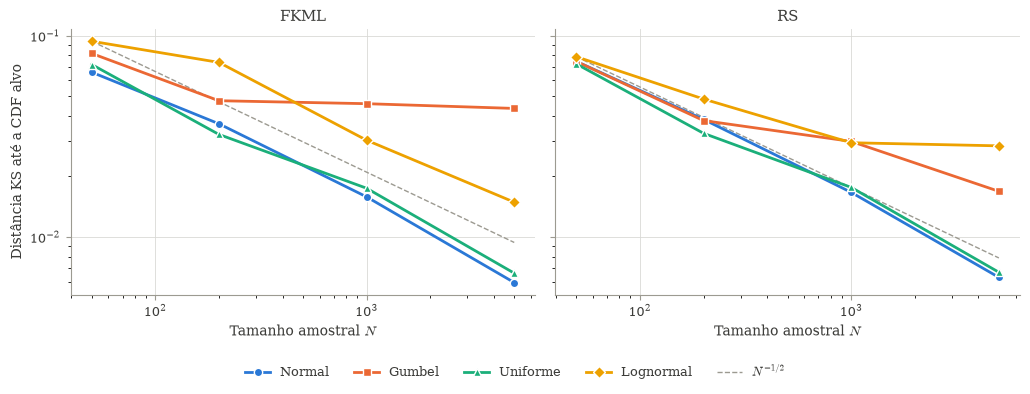

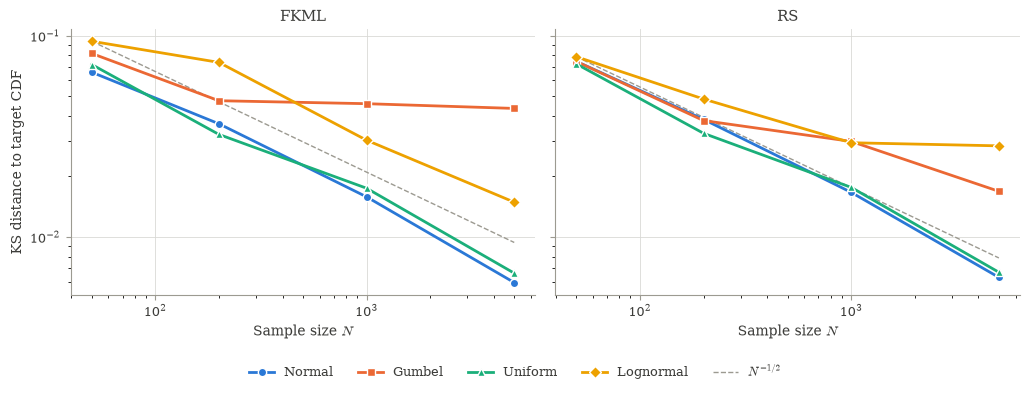

In [12]:
def plot_convergence(lang, save=True):
    L   = labels[lang]
    fig, axes = plt.subplots(1, len(families), figsize=(5.2 * len(families), 3.6),
                             sharey=True, squeeze=False)

    for panel, family in enumerate(families):
        ax = axes[0][panel]
        for i, name in enumerate(targets):
            d = summary[(summary['Family'] == family) &
                        (summary['Distribution'] == name)].sort_values('N')
            if d.empty:
                continue
            ax.plot(d['N'], d['KS'], color=series[i], linewidth=2.0, marker=markers[i],
                    markersize=6, markeredgecolor='white', markeredgewidth=1.0,
                    label=L['names'][name])

        # slope -1/2 guide, anchored on the smallest N of the panel
        anchor = summary[summary['Family'] == family]
        if not anchor.empty:
            n0, y0 = min(sizes), float(anchor[anchor['N'] == min(sizes)]['KS'].max())
            n_ref  = np.array([min(sizes), max(sizes)], dtype=float)
            ax.plot(n_ref, y0 * (n_ref / n0) ** -0.5, color=gray_e, linewidth=1.0,
                    linestyle='--', zorder=1, label='$N^{-1/2}$')

        ax.set_xscale('log'); ax.set_yscale('log')
        ax.set_title(family, fontsize=11, color=ink, pad=6)
        ax.set_xlabel(L['n'], fontsize=10, color=ink)
        ax.grid(True, which='major', color=gray_f, linewidth=0.6, zorder=0)
        ax.set_axisbelow(True)
        for s in ('top', 'right'):
            ax.spines[s].set_visible(False)
        for s in ('left', 'bottom'):
            ax.spines[s].set_color(gray_e); ax.spines[s].set_linewidth(0.8)
        ax.tick_params(colors=ink, labelsize=9, width=0.8, color=gray_e)

    axes[0][0].set_ylabel(L['ks'], fontsize=10, color=ink)
    h, lb = axes[0][0].get_legend_handles_labels()
    fig.legend(h, lb, frameon=False, fontsize=9, labelcolor=ink, ncol=len(lb),
               loc='lower center', bbox_to_anchor=(0.5, -0.10))
    fig.tight_layout()

    if save:
        fig.savefig(fig_dir / f'z_pyglam_convergence_{lang}.{fig_format}',
                    bbox_inches='tight', dpi=fig_dpi)
    return fig


for lang in ('pt', 'en'):
    plot_convergence(lang)
plt.show()

## **9. LaTeX tables**

Written straight into `texto/`, so the manuscript can `\input` them and never holds a number that
was copied by hand.

In [13]:
def num(value, decimals, lang='pt'):
    """Format a number with the decimal separator the target language uses."""

    if not np.isfinite(value):
        return '---'
    text = f'{value:.{decimals}f}'

    return text.replace('.', ',') if lang == 'pt' else text


def num_n(value, lang='pt'):
    """Format a sample size with the thousands separator the target language uses."""

    text = f'{int(value):,}'

    return text.replace(',', '.') if lang == 'pt' else text


def drop_last_terminator(body):
    """Remove the row terminator of the last line of a table body.

    A fragment that ends in ``\\\\`` cannot be ``\\input`` inside a ``tabular``: TeX
    reports a misplaced ``\\noalign`` at the following rule. The manuscript supplies
    the terminator after the ``\\input`` instead.
    """

    body = body.rstrip()

    return body[:-2].rstrip() if body.endswith('\\\\') else body


def latex_metrics(family, lang='pt', decimals=4):
    """Emit the body of the per-parameterization metrics table.

    :param family: Key of `families`
    :param lang: Target language, which sets the number format and the row labels
    :param decimals: Decimal places of the distance columns

    :return: LaTeX source of the table body
    """

    names = labels[lang]['names']
    lines = []

    for name in targets:
        d = summary[(summary['Family'] == family) & (summary['Distribution'] == name)].sort_values('N')
        for _, r in d.iterrows():
            label = names[name] if r['N'] == d['N'].iloc[0] else ''
            cells = [num(r['KS'], decimals, lang), num(r['KL'], decimals, lang),
                     num(r['Wasserstein'], decimals, lang), num(r['err P5 (%)'], 2, lang),
                     num(r['err P50 (%)'], 2, lang), num(r['err P95 (%)'], 2, lang)]
            lines.append(f"{label} & {num_n(r['N'], lang)} & " + ' & '.join(cells) + r' \\')
        lines.append(r'\midrule')

    return drop_last_terminator('\n'.join(lines[:-1]))


for lang in ('pt', 'en'):
    for family in families:
        body = latex_metrics(family, lang)
        (fig_dir / f'z_tab_pyglam_metrics_{family.lower()}_{lang}.tex').write_text(body + '\n', encoding='utf-8')
        print(f'--- {family} / {lang} ---'); print(body); print()

--- FKML / pt ---
Normal & 50 & 0,0659 & 0,1274 & 0,1491 & 5,55 & 3,37 & 7,18 \\
 & 200 & 0,0366 & 0,0316 & 0,0794 & 3,59 & 2,04 & 2,27 \\
 & 1.000 & 0,0158 & 0,0124 & 0,0356 & 1,43 & 0,74 & 1,34 \\
 & 5.000 & 0,0059 & 0,0090 & 0,0212 & 0,46 & 0,28 & 0,53 \\
\midrule
Gumbel & 50 & 0,0818 & 0,3581 & 0,2063 & 5,01 & 3,88 & 9,92 \\
 & 200 & 0,0476 & 0,0813 & 0,1087 & 2,46 & 1,57 & 4,94 \\
 & 1.000 & 0,0460 & 0,0751 & 0,1045 & 1,50 & 1,14 & 4,84 \\
 & 5.000 & 0,0436 & 0,0759 & 0,0893 & 1,23 & 0,93 & 3,24 \\
\midrule
Uniforme & 50 & 0,0720 & 0,0397 & 0,0427 & 3,48 & 5,73 & 2,92 \\
 & 200 & 0,0324 & 0,0050 & 0,0185 & 1,16 & 2,41 & 1,39 \\
 & 1.000 & 0,0175 & 0,0016 & 0,0098 & 0,82 & 1,12 & 0,65 \\
 & 5.000 & 0,0066 & 0,0005 & 0,0048 & 0,21 & 0,48 & 0,21 \\
\midrule
Lognormal & 50 & 0,0940 & 0,2218 & 0,0797 & 4,07 & 4,17 & 13,73 \\
 & 200 & 0,0738 & 0,1245 & 0,0509 & 2,74 & 2,56 & 6,36 \\
 & 1.000 & 0,0303 & 0,0485 & 0,0243 & 1,14 & 0,85 & 2,53 \\
 & 5.000 & 0,0149 & 0,0247 & 0,0148 & 0,57 & 

In [14]:
REGIMES = {
              'pt': {'sampling-limited': 'amostral', 'mixed': 'misto',
                     'structural floor': 'patamar estrutural', 'not estimable': '---'},
              'en': {'sampling-limited': 'sampling-limited', 'mixed': 'mixed',
                     'structural floor': 'structural floor', 'not estimable': '---'},
          }


def latex_rates(lang='pt', decimals=2):
    """Emit the body of the convergence-rate table, all parameterizations in one block."""

    names  = labels[lang]['names']
    regime = REGIMES[lang]
    lines  = []

    for family in families:
        d = rates[rates['Family'] == family]
        for _, r in d.iterrows():
            label = family if r['Distribution'] == d['Distribution'].iloc[0] else ''
            lines.append(f"{label} & {names[r['Distribution']]} & {num(r['slope'], decimals, lang)} & "
                         f"{num(r['R2'], decimals, lang)} & {regime[r['regime']]}" + r' \\')
        lines.append(r'\midrule')

    return drop_last_terminator('\n'.join(lines[:-1]))


for lang in ('pt', 'en'):
    body = latex_rates(lang)
    (fig_dir / f'z_tab_pyglam_rates_{lang}.tex').write_text(body + '\n', encoding='utf-8')
    print(f'--- {lang} ---'); print(body); print()

--- pt ---
FKML & Normal & -0,52 & 0,99 & amostral \\
 & Gumbel & -0,12 & 0,68 & patamar estrutural \\
 & Uniforme & -0,50 & 0,99 & amostral \\
 & Lognormal & -0,42 & 0,97 & misto \\
\midrule
RS & Normal & -0,54 & 1,00 & amostral \\
 & Gumbel & -0,30 & 0,96 & misto \\
 & Uniforme & -0,50 & 0,99 & amostral \\
 & Lognormal & -0,23 & 0,90 & patamar estrutural

--- en ---
FKML & Normal & -0.52 & 0.99 & sampling-limited \\
 & Gumbel & -0.12 & 0.68 & structural floor \\
 & Uniform & -0.50 & 0.99 & sampling-limited \\
 & Lognormal & -0.42 & 0.97 & mixed \\
\midrule
RS & Normal & -0.54 & 1.00 & sampling-limited \\
 & Gumbel & -0.30 & 0.96 & mixed \\
 & Uniform & -0.50 & 0.99 & sampling-limited \\
 & Lognormal & -0.23 & 0.90 & structural floor



## **10. Save**

In [15]:
raw.to_csv(REPO / '00_pyglam_test_raw.csv', index=False)
summary.to_csv(REPO / '00_pyglam_test_summary.csv', index=False)
rates.to_csv(REPO / '00_pyglam_test_rates.csv', index=False)
validity.to_csv(REPO / '00_pyglam_test_validity.csv', index=False)

valid_body = []
for _, r in validity.iterrows():
    label = r['Family'] if r['Distribution'] == validity[validity['Family'] == r['Family']]['Distribution'].iloc[0] else ''
    valid_body.append(f"{label} & {r['Distribution']} & {int(r['fits'])} & "
                      f"{r['candidates valid (%)']:.1f} & {r['valid unscreened (%)']:.1f} & "
                      f"{r['valid (%)']:.1f}" + r' \\')
(fig_dir / 'z_tab_pyglam_validity_en.tex').write_text(
    drop_last_terminator('\n'.join(valid_body)) + '\n', encoding='utf-8')

print('saved: 00_pyglam_test_{raw,summary,rates,validity}.csv')
print(f'figures: {fig_dir}/z_pyglam_{{fits,convergence}}_{{pt,en}}.{fig_format}')
print(f'tables:  {fig_dir}/z_tab_pyglam_{{metrics_*,rates_*,validity_en}}.tex')

saved: 00_pyglam_test_{raw,summary,rates,validity}.csv
figures: /home/casa-wand/steam2tb/pyGLAM/texto/z_pyglam_{fits,convergence}_{pt,en}.pdf
tables:  /home/casa-wand/steam2tb/pyGLAM/texto/z_tab_pyglam_{metrics_*,rates_*,validity_en}.tex
